# sPHENIX TPC 3D ion-backflow field generator

This notebook builds a realistic side/sector/module-dependent ion charge distribution, optionally estimates and fits its radial power law, performs a memory-bounded Green-function convolution, and writes local Cartesian field maps for `PHGarfield`.

In [1]:
import re, json, time
from pathlib import Path
import numpy as np
import ROOT
from scipy import optimize, special, integrate
import matplotlib.pyplot as plt

ROOT.gROOT.SetBatch(True)
EPSILON_0 = 8.8541878128e-12
CM_TO_M = 1.0e-2
M_TO_CM = 100.0


Welcome to JupyROOT 6.30/06


## Configuration

In [2]:
# Input files
PAD_PLACEMENT_FILE = Path("../input/TPC_pad_placement.txt")
GAIN_MAP_FILE = Path("../input/dbb9e854-b14e-488e-9991-8f6f1962dffb.txt")
GAIN_METHOD = 1                         # 1 or 2
MULTIPLY_CHARGE_BY_GAIN = True          # requested convention
NORMALIZE_GAIN_WEIGHTED_TOTAL = True    # preserve total charge after introducing asymmetry

# Radial model
GENERATE_RADIAL_STUDY = True
FIT_GENERATED_CHARGE = True             # False -> use FIXED_ALPHA/FIXED_CONSTANT
GENERATION_MODE = "flat_eta"            # "flat_eta" or "isotropic_sphere"
N_GENERATED = 2_000_000
ETA_MAX = 3.5
Z_GEM_CM = 102.325
FIT_R_MIN_CM = 22.8132065669
FIT_R_MAX_CM = 75.9666751734
FIXED_ALPHA = np.array([2.0, 2.0, 2.0], dtype=float)
FIXED_CONSTANT = np.array([1.0, 1.0, 1.0], dtype=float)

# TPC electrostatic volume and GEM/module boundaries
A_CM, B_CM, L_CM = 20.0, 75.911, 102.325
# R1 includes the antenna-pad GEM area as requested.
MODULE_R_BOUNDS_CM = np.array([
    [22.8132065669, 40.0513196955],
    [41.6592025362 - 0.5*1.3179431693, 56.9695394315 + 0.5*1.3179431693],
    [58.9109633493 - 0.5*1.3175606263, 75.3666751734 + 0.5*1.3175606263],
])

# Source and observation grids. Increase NPHI only after a small validation run.
NR_SRC, NPHI_SRC, NZ_SRC = 36, 48, 40
NR_OBS, NPHI_OBS, NZ_OBS = 36, 48, 40
M_PHI_MAX = int(24/2)
N_RADIAL_MODES = int(28/2)
N_LONGITUDINAL_MODES = int(28/2)
OBS_BLOCK = 1024
SRC_BLOCK = 4096

M_PHI_MAX = 12
N_RADIAL_MODES = 14
N_LONGITUDINAL_MODES = 14

OBS_BLOCK = 256
SRC_BLOCK = 1024


# Coarse local validation grid
NR_SRC = 20
NPHI_SRC = 36
NZ_SRC = 24

NR_OBS = 20
NPHI_OBS = 36
NZ_OBS = 24

# Truncated Green-function expansion
M_PHI_MAX = 4
N_RADIAL_MODES = 6
N_LONGITUDINAL_MODES = 6

OBS_BLOCK = 256
SRC_BLOCK = 1024

RHO_REFERENCE_NC_PER_M3 = 20.0
K_EFF = 1.0
OUTPUT_ROOT = "sphenix_3d_ibf_field.root"
SAVE_CHARGE_MAP = True


## Parse real sector/module geometry and module gain map

In [3]:
def wrap_phi(phi):
    return (phi + np.pi) % (2*np.pi) - np.pi

def parse_pad_geometry(path):
    text = Path(path).read_text(errors="ignore")
    region = None
    data = {}
    for line in text.splitlines():
        m = re.search(r"region\s+(\d+)\s+first_layer", line)
        if m:
            region = int(m.group(1))
            continue
        m = re.search(r"side\s+(\d+)\s+sector\s+(\d+).*?first_phi\s+([-+0-9.eE]+).*?last_phi\s+([-+0-9.eE]+)", line)
        if m and region is not None and (region, int(m.group(1)), int(m.group(2))) not in data:
            side, sec = int(m.group(1)), int(m.group(2))
            first_phi, last_phi = float(m.group(3)), float(m.group(4))
            # Pad centers. Extend by half a pad pitch on both sides to get the active edge.
            delta = wrap_phi(last_phi - first_phi)
            npads = (94, 128, 192)[region]
            pitch = delta/(npads-1)
            edge0 = wrap_phi(first_phi - 0.5*pitch)
            edge1 = wrap_phi(last_phi + 0.5*pitch)
            data[(region, side, sec)] = (edge0, edge1)
    if len(data) != 3*2*12:
        raise RuntimeError(f"Expected 72 geometry entries, found {len(data)}")
    return data

def phi_in_interval(phi, edge0, edge1):
    width = (edge1-edge0) % (2*np.pi)
    return ((phi-edge0) % (2*np.pi)) <= width

def parse_gain_map(path, method=1):
    text = Path(path).read_text(errors="ignore")
    gain = np.ones((2, 12, 3), dtype=float)
    # Full-table columns end in Gain_m1 Gain_m2.
    pat = re.compile(r"^\s*([01])\s+(\d{1,2})\s+([123])\s+\d+\s+\d+\s+[-+0-9.eE]+\s+[yn]\s+[-+0-9.eE]+\s+[yn]\s+[-+0-9.eE]+\s+([-+0-9.eE]+)\s+([-+0-9.eE]+)\s*$")
    found = 0
    for line in text.splitlines():
        m = pat.match(line)
        if not m: continue
        side, sec, mod = int(m.group(1)), int(m.group(2)), int(m.group(3))-1
        gain[side, sec, mod] = float(m.group(4 if method == 1 else 5))
        found += 1
    if found != 72:
        raise RuntimeError(f"Expected 72 gain entries, found {found}")
    return gain

pad_geometry = parse_pad_geometry(PAD_PLACEMENT_FILE)
gain_map = parse_gain_map(GAIN_MAP_FILE, GAIN_METHOD)
print("Module radial bounds [cm]:\n", MODULE_R_BOUNDS_CM)
print("Gain range:", gain_map.min(), gain_map.max(), "mean:", gain_map.mean())


Module radial bounds [cm]:
 [[22.81320657 40.0513197 ]
 [41.00023095 57.62851102]
 [58.25218304 76.02545549]]
Gain range: 0.801074 1.444409 mean: 1.0361793194444444


## Generate charge from spherical emission or flat pseudorapidity and optionally fit $C/r^\alpha$

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import optimize


# ------------------------------------------------------------
# Radial-study configuration
# ------------------------------------------------------------

GENERATE_RADIAL_STUDY = True
FIT_GENERATED_CHARGE = True

GENERATION_MODE = "realistic_eta"

# Available:
#   "flat_eta"
#   "realistic_eta"
#   "isotropic_sphere"

ETA_DISTRIBUTION = "double_hump"

# Generate the underlying particle distribution in this range.
ETA_MAX = 3.0

# GEM/endcap plane distance from the interaction point.
Z_GEM_CM = 102.325

# Active radial range used for the study.
FIT_R_MIN_CM = 22.8132065669
FIT_R_MAX_CM = 75.915

# Monte Carlo statistics.
N_GENERATED = 2_000_000

# Number of radial bins.
RADIAL_FIT_BINS = 70

# ------------------------------------------------------------
# Double-hump dN/deta shape
# ------------------------------------------------------------

ETA_PEAK = 2.15
ETA_PEAK_WIDTH = 1.35
ETA_HUMP_AMPLITUDE = 0.35

ETA_CENTRAL_DIP = 0.08
ETA_CENTRAL_WIDTH = 0.55

# Smooth suppression only at large |eta|.
ETA_EDGE_START = 4.0
ETA_EDGE_WIDTH = 0.65

# ------------------------------------------------------------
# Fixed values used when FIT_GENERATED_CHARGE = False
# ------------------------------------------------------------

FIXED_ALPHA = np.array(
    [1.20, 1.20, 1.20],
    dtype=float,
)

FIXED_CONSTANT = np.array(
    [1.0, 1.0, 1.0],
    dtype=float,
)

In [5]:
def eta_weight(eta, model):
    eta = np.asarray(eta, dtype=float)
    abs_eta = np.abs(eta)

    if model == "flat":
        weight = np.ones_like(eta)

    elif model == "double_hump":
        hump = np.exp(
            -0.5
            * (
                (abs_eta - ETA_PEAK)
                / ETA_PEAK_WIDTH
            ) ** 2
        )

        hump_shape = (
            1.0
            + ETA_HUMP_AMPLITUDE * hump
        )

        central_shape = (
            1.0
            - ETA_CENTRAL_DIP
            * np.exp(
                -0.5
                * (
                    eta
                    / ETA_CENTRAL_WIDTH
                ) ** 2
            )
        )

        edge_shape = 0.5 * (
            1.0
            - np.tanh(
                (
                    abs_eta
                    - ETA_EDGE_START
                )
                / ETA_EDGE_WIDTH
            )
        )

        weight = (
            hump_shape
            * central_shape
            * edge_shape
        )

    else:
        raise ValueError(
            f"Unknown ETA_DISTRIBUTION={model!r}"
        )

    maximum = np.max(weight)

    if maximum <= 0.0:
        raise RuntimeError(
            "Eta model has no positive weight."
        )

    return np.clip(
        weight / maximum,
        0.0,
        1.0,
    )

def sample_eta_rejection(
    rng,
    n,
    eta_max,
    model,
):
    """
    Generate signed eta values in [-eta_max, eta_max]
    according to the selected dN/deta model.
    """
    accepted = []
    n_accepted = 0

    while n_accepted < n:
        remaining = n - n_accepted

        n_try = max(
            100_000,
            2 * remaining,
        )

        eta_try = rng.uniform(
            -eta_max,
            eta_max,
            n_try,
        )

        weight = eta_weight(
            eta_try,
            model=model,
        )

        keep = (
            rng.random(n_try)
            < weight
        )

        selected = eta_try[keep]

        accepted.append(selected)
        n_accepted += len(selected)

    return np.concatenate(
        accepted
    )[:n]


def eta_to_gem_radius(
    eta,
    z_plane_cm,
):
    """
    Radius where a ray from the origin reaches the plane
    z = +/-z_plane_cm.

    r = z / sinh(|eta|)
    """
    eta = np.asarray(
        eta,
        dtype=float,
    )

    abs_eta = np.abs(eta)

    radius = np.full(
        abs_eta.shape,
        np.nan,
        dtype=float,
    )

    valid = abs_eta > 1.0e-12

    radius[valid] = (
        z_plane_cm
        / np.sinh(abs_eta[valid])
    )

    return radius


def generate_cylinder_radii(
    n,
    mode,
    z_plane_cm,
    r_min_cm,
    r_max_cm,
    eta_max,
    seed=12345,
):
    rng = np.random.default_rng(seed)

    if mode == "flat_eta":
        eta = rng.uniform(
            -eta_max,
            eta_max,
            n,
        )

    elif mode == "realistic_eta":
        eta = sample_eta_rejection(
            rng=rng,
            n=n,
            eta_max=eta_max,
            model=ETA_DISTRIBUTION,
        )

    elif mode == "isotropic_sphere":
        cos_theta = rng.uniform(
            -1.0,
            1.0,
            n,
        )

        theta = np.arccos(
            cos_theta
        )

        eta = -np.log(
            np.tan(
                theta / 2.0
            )
        )

    else:
        raise ValueError(
            f"Unknown generation mode {mode!r}. "
            "Use 'flat_eta', 'realistic_eta', "
            "or 'isotropic_sphere'."
        )

    radius = eta_to_gem_radius(
        eta,
        z_plane_cm,
    )

    phi = rng.uniform(
        -np.pi,
        np.pi,
        n,
    )

    active = (
        np.isfinite(radius)
        & (radius >= r_min_cm)
        & (radius <= r_max_cm)
    )

    return (
        radius[active],
        phi[active],
        eta[active],
        eta,
    )

Generated particles: 2000000
Particles reaching active GEM radius: 775980
Acceptance fraction: 0.387990
Active GEM corresponds approximately to:
  1.107315 < |eta| < 2.206163


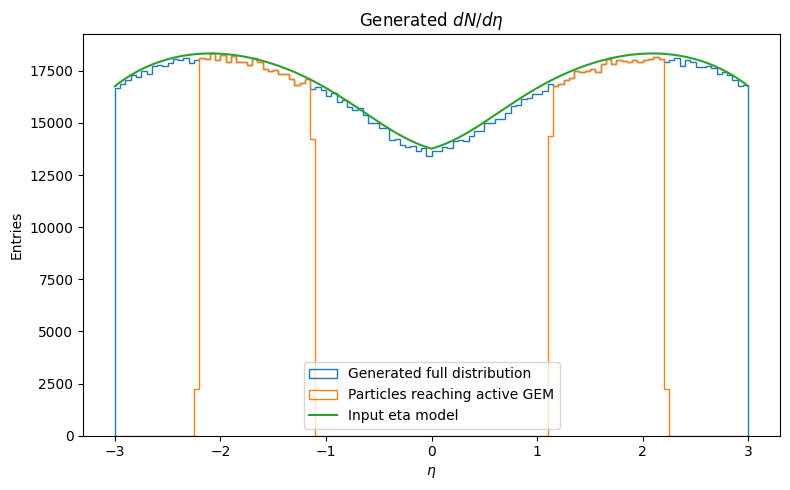

Fit result:
  C = 1469268.4 +/- 17751.617
  alpha = 1.22154642 +/- 0.00324927


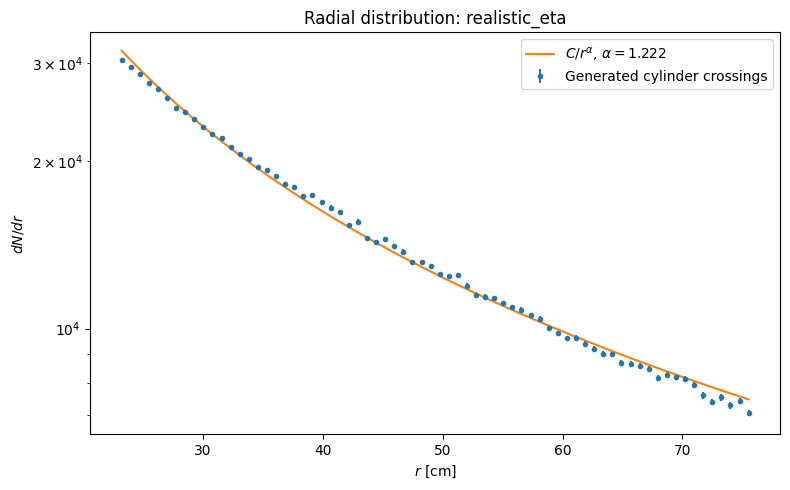

Using fitted radial charge parameters.
RADIAL_ALPHA    = [1.22154642 1.22154642 1.22154642]
RADIAL_CONSTANT = [1469268.43839378 1469268.43839378 1469268.43839378]


In [6]:
def power_law(
    radius,
    constant,
    alpha,
):
    return (
        constant
        / np.power(radius, alpha)
    )


def fit_radial_distribution(
    radii,
    r_min_cm,
    r_max_cm,
    nbins,
):
    edges = np.linspace(
        r_min_cm,
        r_max_cm,
        nbins + 1,
    )

    counts, _ = np.histogram(
        radii,
        bins=edges,
    )

    centers = 0.5 * (
        edges[:-1]
        + edges[1:]
    )

    widths = np.diff(edges)

    dndr = counts / widths

    dndr_error = (
        np.sqrt(
            np.maximum(
                counts,
                1.0,
            )
        )
        / widths
    )

    fit_mask = counts >= 20

    if np.count_nonzero(fit_mask) < 5:
        raise RuntimeError(
            "Too few populated radial bins "
            "for a stable power-law fit."
        )

    log_r = np.log(
        centers[fit_mask]
    )

    log_y = np.log(
        dndr[fit_mask]
    )

    slope, intercept = np.polyfit(
        log_r,
        log_y,
        1,
    )

    alpha_initial = max(
        0.0,
        -slope,
    )

    constant_initial = np.exp(
        intercept
    )

    fitted_parameters, covariance = (
        optimize.curve_fit(
            power_law,
            centers[fit_mask],
            dndr[fit_mask],
            p0=(
                constant_initial,
                alpha_initial,
            ),
            sigma=dndr_error[fit_mask],
            absolute_sigma=True,
            bounds=(
                [0.0, 0.0],
                [np.inf, 10.0],
            ),
            maxfev=100_000,
        )
    )

    return (
        centers,
        dndr,
        dndr_error,
        counts,
        fit_mask,
        fitted_parameters,
        covariance,
    )


fitted_c = None
fitted_alpha = None
fitted_covariance = None


if GENERATE_RADIAL_STUDY:
    (
        generated_r,
        generated_phi,
        generated_eta_active,
        generated_eta_all,
    ) = generate_cylinder_radii(
        n=N_GENERATED,
        mode=GENERATION_MODE,
        z_plane_cm=Z_GEM_CM,
        r_min_cm=FIT_R_MIN_CM,
        r_max_cm=FIT_R_MAX_CM,
        eta_max=ETA_MAX,
    )

    print(
        f"Generated particles: {N_GENERATED}"
    )

    print(
        f"Particles reaching active GEM radius: "
        f"{len(generated_r)}"
    )

    print(
        f"Acceptance fraction: "
        f"{len(generated_r) / N_GENERATED:.6f}"
    )

    eta_min_for_outer_radius = np.arcsinh(
        Z_GEM_CM / FIT_R_MAX_CM
    )

    eta_max_for_inner_radius = np.arcsinh(
        Z_GEM_CM / FIT_R_MIN_CM
    )

    print(
        "Active GEM corresponds approximately to:"
    )

    print(
        f"  {eta_min_for_outer_radius:.6f}"
        f" < |eta| < "
        f"{eta_max_for_inner_radius:.6f}"
    )

    # --------------------------------------------------------
    # QA plot: generated eta distribution
    # --------------------------------------------------------

    eta_plot = np.linspace(
        -ETA_MAX,
        ETA_MAX,
        1000,
    )

    if GENERATION_MODE == "realistic_eta":
        input_eta_weight = eta_weight(
            eta_plot,
            model=ETA_DISTRIBUTION,
        )

    elif GENERATION_MODE == "flat_eta":
        input_eta_weight = np.ones_like(
            eta_plot
        )

    else:
        input_eta_weight = None

    plt.figure(
        figsize=(8, 5)
    )

    eta_counts, eta_edges, _ = plt.hist(
        generated_eta_all,
        bins=120,
        range=(-ETA_MAX, ETA_MAX),
        histtype="step",
        label="Generated full distribution",
    )

    plt.hist(
        generated_eta_active,
        bins=120,
        range=(-ETA_MAX, ETA_MAX),
        histtype="step",
        label="Particles reaching active GEM",
    )

    if input_eta_weight is not None:
        model_scale = np.max(
            eta_counts
        )

        plt.plot(
            eta_plot,
            model_scale
            * input_eta_weight,
            label="Input eta model",
        )

    plt.xlabel(
        r"$\eta$"
    )

    plt.ylabel(
        "Entries"
    )

    plt.title(
        r"Generated $dN/d\eta$"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Fit radial distribution
    # --------------------------------------------------------

    (
        radial_centers,
        dndr,
        dndr_error,
        radial_counts,
        radial_fit_mask,
        fitted_parameters,
        fitted_covariance,
    ) = fit_radial_distribution(
        radii=generated_r,
        r_min_cm=FIT_R_MIN_CM,
        r_max_cm=FIT_R_MAX_CM,
        nbins=RADIAL_FIT_BINS,
    )

    fitted_c = fitted_parameters[0]
    fitted_alpha = fitted_parameters[1]

    fitted_c_error = np.sqrt(
        fitted_covariance[0, 0]
    )

    fitted_alpha_error = np.sqrt(
        fitted_covariance[1, 1]
    )

    print(
        "Fit result:"
    )

    print(
        f"  C = {fitted_c:.8g}"
        f" +/- {fitted_c_error:.8g}"
    )

    print(
        f"  alpha = {fitted_alpha:.8f}"
        f" +/- {fitted_alpha_error:.8f}"
    )

    radial_plot = np.linspace(
        radial_centers[
            radial_fit_mask
        ].min(),
        radial_centers[
            radial_fit_mask
        ].max(),
        1000,
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.errorbar(
        radial_centers[
            radial_fit_mask
        ],
        dndr[
            radial_fit_mask
        ],
        yerr=dndr_error[
            radial_fit_mask
        ],
        fmt=".",
        label="Generated cylinder crossings",
    )

    plt.plot(
        radial_plot,
        power_law(
            radial_plot,
            fitted_c,
            fitted_alpha,
        ),
        label=(
            rf"$C/r^{{\alpha}}$, "
            rf"$\alpha={fitted_alpha:.3f}$"
        ),
    )

    plt.yscale(
        "log"
    )

    plt.xlabel(
        r"$r$ [cm]"
    )

    plt.ylabel(
        r"$dN/dr$"
    )

    plt.title(
        "Radial distribution: "
        f"{GENERATION_MODE}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Choose parameters for the field calculation
# ------------------------------------------------------------

if FIT_GENERATED_CHARGE:
    if (
        fitted_c is None
        or fitted_alpha is None
    ):
        raise RuntimeError(
            "FIT_GENERATED_CHARGE=True requires "
            "GENERATE_RADIAL_STUDY=True."
        )

    RADIAL_ALPHA = np.full(
        3,
        fitted_alpha,
        dtype=float,
    )

    RADIAL_CONSTANT = np.full(
        3,
        fitted_c,
        dtype=float,
    )

    print(
        "Using fitted radial charge parameters."
    )

else:
    RADIAL_ALPHA = (
        FIXED_ALPHA.copy()
    )

    RADIAL_CONSTANT = (
        FIXED_CONSTANT.copy()
    )

    print(
        "Using fixed radial charge parameters."
    )


print(
    "RADIAL_ALPHA    =",
    RADIAL_ALPHA,
)

print(
    "RADIAL_CONSTANT =",
    RADIAL_CONSTANT,
)

In [7]:
if False:
    def generate_cylinder_radii(
        n,
        mode,
        z_plane_cm,
        r_min_cm,
        r_max_cm,
        eta_max=None,
        seed=12345,
    ):
        rng = np.random.default_rng(seed)
    
        if mode == "flat_eta":
            # Minimum eta needed to reach the outer radius.
            eta_min_required = np.arcsinh(z_plane_cm / r_max_cm)
    
            # Maximum eta needed to reach the inner radius.
            eta_max_required = np.arcsinh(z_plane_cm / r_min_cm)
    
            if eta_max is None:
                eta_max_used = eta_max_required
            else:
                eta_max_used = max(float(eta_max), eta_max_required)
    
            # A track reaching either GEM endcap has positive |eta|.
            abs_eta = rng.uniform(
                eta_min_required,
                eta_max_used,
                n,
            )
    
            # Randomly assign positive/negative eta for the two TPC sides.
            eta_sign = rng.choice(
                np.array([-1.0, 1.0]),
                size=n,
            )
            eta = eta_sign * abs_eta
    
            r = z_plane_cm / np.sinh(abs_eta)
            phi = rng.uniform(-np.pi, np.pi, n)
    
            print(
                "Flat-eta generation range:"
                f" |eta| = {eta_min_required:.6f}"
                f" to {eta_max_used:.6f}"
            )
    
        elif mode == "isotropic_sphere":
            # Generate directions isotropically in solid angle.
            cos_theta = rng.uniform(-1.0, 1.0, n)
    
            # Distance from the beam axis where the ray reaches z=+/-z_plane.
            sin_theta = np.sqrt(
                np.maximum(0.0, 1.0 - cos_theta**2)
            )
    
            valid_direction = np.abs(cos_theta) > 1.0e-12
    
            r = np.full(n, np.nan)
            r[valid_direction] = (
                z_plane_cm
                * sin_theta[valid_direction]
                / np.abs(cos_theta[valid_direction])
            )
    
            phi = rng.uniform(-np.pi, np.pi, n)
    
        else:
            raise ValueError(
                f"Unknown mode {mode!r}. "
                "Use 'flat_eta' or 'isotropic_sphere'."
            )
    
        keep = (
            np.isfinite(r)
            & (r >= r_min_cm)
            & (r <= r_max_cm)
        )
    
        return r[keep], phi[keep]
    
    
    def power_law(r, c, alpha):
        return c / np.power(r, alpha)
    
    
    def fit_radial_distribution(
        radii,
        r_min_cm,
        r_max_cm,
        nbins=70,
    ):
        edges = np.linspace(
            r_min_cm,
            r_max_cm,
            nbins + 1,
        )
    
        counts, _ = np.histogram(
            radii,
            bins=edges,
        )
    
        centers = 0.5 * (
            edges[:-1] + edges[1:]
        )
        widths = np.diff(edges)
    
        # Charge/count per unit radial interval.
        dndr = counts / widths
    
        dndr_error = (
            np.sqrt(np.maximum(counts, 1.0))
            / widths
        )
    
        # Only fit bins with sufficient statistics.
        use = counts >= 20
    
        if np.count_nonzero(use) < 4:
            raise RuntimeError(
                "Too few populated bins for a stable power-law fit."
            )
    
        # Get a robust initial alpha from a log-linear fit:
        #
        # log(dN/dr) = log(C) - alpha*log(r)
        log_r = np.log(centers[use])
        log_y = np.log(dndr[use])
    
        slope, intercept = np.polyfit(
            log_r,
            log_y,
            1,
        )
    
        alpha_initial = max(0.0, -slope)
        c_initial = np.exp(intercept)
    
        fitted, covariance = optimize.curve_fit(
            power_law,
            centers[use],
            dndr[use],
            p0=(c_initial, alpha_initial),
            sigma=dndr_error[use],
            absolute_sigma=True,
            bounds=(
                [0.0, 0.0],
                [np.inf, 10.0],
            ),
            maxfev=50000,
        )
    
        return (
            centers,
            dndr,
            dndr_error,
            counts,
            use,
            fitted,
            covariance,
        )
    
    
    fitted_c = None
    fitted_alpha = None
    fitted_cov = None
    
    if GENERATE_RADIAL_STUDY:
        generated_r, generated_phi = generate_cylinder_radii(
            n=N_GENERATED,
            mode=GENERATION_MODE,
            z_plane_cm=Z_GEM_CM,
            r_min_cm=FIT_R_MIN_CM,
            r_max_cm=FIT_R_MAX_CM,
            eta_max=ETA_MAX,
        )
    
        (
            centers,
            dndr,
            dndr_error,
            counts,
            fit_mask,
            fitted,
            fitted_cov,
        ) = fit_radial_distribution(
            generated_r,
            r_min_cm=FIT_R_MIN_CM,
            r_max_cm=FIT_R_MAX_CM,
        )
    
        fitted_c, fitted_alpha = fitted
        fitted_alpha_error = np.sqrt(
            fitted_cov[1, 1]
        )
    
        print(
            f"{GENERATION_MODE}: accepted "
            f"{len(generated_r)} / {N_GENERATED}"
        )
    
        print(
            "Fit dN/dr = C/r^alpha:\n"
            f"  C     = {fitted_c:.8g}\n"
            f"  alpha = {fitted_alpha:.8f}"
            f" +/- {fitted_alpha_error:.8f}"
        )
    
        plt.figure(figsize=(8, 5))
    
        plt.errorbar(
            centers[fit_mask],
            dndr[fit_mask],
            yerr=dndr_error[fit_mask],
            fmt=".",
            label="Generated cylinder crossings",
        )
    
        r_plot = np.linspace(
            centers[fit_mask].min(),
            centers[fit_mask].max(),
            500,
        )
    
        plt.plot(
            r_plot,
            power_law(
                r_plot,
                fitted_c,
                fitted_alpha,
            ),
            label=(
                rf"$C/r^{{\alpha}}$, "
                rf"$\alpha={fitted_alpha:.3f}$"
            ),
        )
    
        plt.yscale("log")
        plt.xlabel(r"$r$ [cm]")
        plt.ylabel(r"$dN/dr$")
        plt.title(
            f"Radial distribution: {GENERATION_MODE}"
        )
        plt.legend()
        plt.tight_layout()
        plt.show()
    
    else:
        fitted_c = None
        fitted_alpha = None
    
    
    if FIT_GENERATED_CHARGE:
        if fitted_c is None or fitted_alpha is None:
            raise RuntimeError(
                "FIT_GENERATED_CHARGE=True requires "
                "GENERATE_RADIAL_STUDY=True."
            )
    
        RADIAL_ALPHA = np.full(
            3,
            fitted_alpha,
            dtype=float,
        )
    
        RADIAL_CONSTANT = np.full(
            3,
            fitted_c,
            dtype=float,
        )
    
        print("Using fitted radial parameters.")
    
    else:
        RADIAL_ALPHA = FIXED_ALPHA.copy()
        RADIAL_CONSTANT = FIXED_CONSTANT.copy()
    
        print("Using fixed radial parameters.")
    
    
    print("RADIAL_ALPHA    =", RADIAL_ALPHA)
    print("RADIAL_CONSTANT =", RADIAL_CONSTANT)

## Build signed-$z$ 3D source density using real GEM masks and gain multiplication

In [8]:
a, b, L = A_CM*CM_TO_M, B_CM*CM_TO_M, L_CM*CM_TO_M
r_src_edges = np.linspace(a, b, NR_SRC+1)
phi_src_edges = np.linspace(-np.pi, np.pi, NPHI_SRC+1)
z_src_edges = np.linspace(-L, L, NZ_SRC+1)
r_src = 0.5*(r_src_edges[:-1]+r_src_edges[1:])
phi_src = 0.5*(phi_src_edges[:-1]+phi_src_edges[1:])
z_src = 0.5*(z_src_edges[:-1]+z_src_edges[1:])

dr = np.diff(r_src_edges)[:,None,None]
dphi = np.diff(phi_src_edges)[None,:,None]
dz = np.diff(z_src_edges)[None,None,:]
dV = r_src[:,None,None]*dr*dphi*dz

rho_shape = np.zeros((NR_SRC,NPHI_SRC,NZ_SRC), dtype=np.float64)
cell_gain = np.ones_like(rho_shape)
cell_module = -np.ones_like(rho_shape, dtype=np.int8)

for ir, r_m in enumerate(r_src):
    r_cm = r_m*M_TO_CM
    module = next((m for m,(lo,hi) in enumerate(MODULE_R_BOUNDS_CM) if lo <= r_cm <= hi), None)
    if module is None: continue
    radial = RADIAL_CONSTANT[module] / r_cm**RADIAL_ALPHA[module]
    for ip, phi in enumerate(phi_src):
        for iz, z_m in enumerate(z_src):
            side = 0 if z_m > 0 else 1
            sector = next((s for s in range(12) if phi_in_interval(phi, *pad_geometry[(module,side,s)])), None)
            if sector is None: continue
            g = gain_map[side,sector,module] if MULTIPLY_CHARGE_BY_GAIN else 1.0
            rho_shape[ir,ip,iz] = radial*g
            cell_gain[ir,ip,iz] = g
            cell_module[ir,ip,iz] = module

active = rho_shape > 0
if not np.any(active): raise RuntimeError("No active GEM/source cells")
if NORMALIZE_GAIN_WEIGHTED_TOTAL and MULTIPLY_CHARGE_BY_GAIN:
    # Remove only the overall gain-induced normalization while preserving the r model and asymmetry.
    base = np.zeros_like(rho_shape)
    base[active] = rho_shape[active]/cell_gain[active]
    norm = np.sum(base*dV)/np.sum(rho_shape*dV)
    rho_shape *= norm

target_rho = K_EFF*RHO_REFERENCE_NC_PER_M3*1e-9
rho = target_rho*rho_shape/(np.sum(rho_shape*dV)/np.sum(dV[active]))
charge = rho*dV
print("Active fraction:", active.mean())
print("Total charge [C]:", charge.sum())


Active fraction: 0.85
Total charge [C]: 6.03189503747513e-08


## Modal Green-function preparation

In [9]:
def F(k,m):
    return special.jv(m,k*b)*special.yv(m,k*a)-special.yv(m,k*b)*special.jv(m,k*a)
def Rfun(k,m,r):
    return special.jv(m,k*r)*special.yv(m,k*a)-special.yv(m,k*r)*special.jv(m,k*a)
def dRfun(k,m,r):
    return k*(special.jvp(m,k*r,1)*special.yv(m,k*a)-special.yvp(m,k*r,1)*special.jv(m,k*a))
def roots_for_m(m,nroot):
    roots=[]; step=0.2*np.pi/(b-a); x=max(1e-6,0.1*np.pi/(b-a)); fx=F(x,m)
    xmax=(nroot+m+30)*np.pi/(b-a)
    while x+step <= xmax and len(roots)<nroot:
        y=x+step; fy=F(y,m)
        if np.isfinite(fx) and np.isfinite(fy) and fx*fy<0:
            rt=optimize.brentq(F,x,y,args=(m,))
            if not roots or abs(rt-roots[-1])>1e-9: roots.append(rt)
        x,fx=y,fy
    if len(roots)!=nroot: raise RuntimeError(f"Only {len(roots)} roots for m={m}")
    return np.asarray(roots)

def radial_norm(k,m):
    val,_=integrate.quad(lambda rr: rr*Rfun(k,m,rr)**2, a, b, epsabs=1e-10, epsrel=1e-8, limit=200)
    return val

k_modes={}; radial_norms={}
for m in range(M_PHI_MAX+1):
    k_modes[m]=roots_for_m(m,N_RADIAL_MODES)
    radial_norms[m]=np.array([radial_norm(k,m) for k in k_modes[m]])
q_modes=np.arange(1,N_LONGITUDINAL_MODES+1)*np.pi/(2*L)


## Memory-bounded convolution (kernels are never stored)

In [10]:
from tqdm.auto import tqdm

In [11]:
r_obs_edges = np.linspace(a, b, NR_OBS + 1)
phi_obs_edges = np.linspace(-np.pi, np.pi, NPHI_OBS + 1)
z_obs_edges = np.linspace(-L, L, NZ_OBS + 1)

r_obs = 0.5 * (r_obs_edges[:-1] + r_obs_edges[1:])
phi_obs = 0.5 * (phi_obs_edges[:-1] + phi_obs_edges[1:])
z_obs = 0.5 * (z_obs_edges[:-1] + z_obs_edges[1:])

Robs, Pobs, Zobs = np.meshgrid(
    r_obs,
    phi_obs,
    z_obs,
    indexing="ij",
)

Rsrc, Psrc, Zsrc = np.meshgrid(
    r_src,
    phi_src,
    z_src,
    indexing="ij",
)

obs = np.column_stack(
    [
        Robs.ravel(),
        Pobs.ravel(),
        Zobs.ravel(),
    ]
)

src = np.column_stack(
    [
        Rsrc.ravel(),
        Psrc.ravel(),
        Zsrc.ravel(),
    ]
)

qsrc = charge.ravel()

keep = qsrc != 0

src = src[keep]
qsrc = qsrc[keep]

Ex = np.zeros(len(obs))
Ey = np.zeros(len(obs))
Ez = np.zeros(len(obs))
Phi = np.zeros(len(obs))

start = time.time()

n_obs_blocks = (
    len(obs) + OBS_BLOCK - 1
) // OBS_BLOCK

n_src_blocks = (
    len(src) + SRC_BLOCK - 1
) // SRC_BLOCK

# Dirichlet boundaries at z = -L,+L use
# u = z + L in [0, 2L].
obs_progress = tqdm(
    range(0, len(obs), OBS_BLOCK),
    total=n_obs_blocks,
    desc="Observation blocks",
    unit="block",
)

for obs_index, o0 in enumerate(obs_progress, start=1):
    ob = obs[o0:o0 + OBS_BLOCK]

    ro, po, zo = ob.T
    uo = zo + L

    e_r = np.zeros(len(ob))
    e_p = np.zeros(len(ob))
    e_z = np.zeros(len(ob))
    pot = np.zeros(len(ob))

    block_start = time.time()

    src_progress = tqdm(
        range(0, len(src), SRC_BLOCK),
        total=n_src_blocks,
        desc=f"Sources for obs {obs_index}/{n_obs_blocks}",
        unit="block",
        leave=False,
    )

    for src_index, s0 in enumerate(src_progress, start=1):
        sb = src[s0:s0 + SRC_BLOCK]
        qs = qsrc[s0:s0 + SRC_BLOCK]

        rs, ps, zs = sb.T
        us = zs + L

        dph = (
            po[:, None]
            - ps[None, :]
        )

        for m in range(M_PHI_MAX + 1):
            pref = (
                2.0 if m > 0 else 1.0
            ) / (2.0 * np.pi)

            c = np.cos(m * dph)
            sn = np.sin(m * dph)

            for k, norm in zip(
                k_modes[m],
                radial_norms[m],
            ):
                rr_o = Rfun(k, m, ro)
                drr_o = dRfun(k, m, ro)
                rr_s = Rfun(k, m, rs)

                radial = (
                    np.outer(rr_o, rr_s)
                    / norm
                )

                radial_r = (
                    -np.outer(drr_o, rr_s)
                    / norm
                )

                if m > 0:
                    radial_p = (
                        m / ro[:, None]
                    ) * radial
                else:
                    radial_p = None

                for q in q_modes:
                    den = k * k + q * q

                    zpart = (
                        1.0 / L
                    ) * (
                        np.outer(
                            np.sin(q * uo),
                            np.sin(q * us),
                        )
                        / den
                    )

                    zder = (
                        -1.0 / L
                    ) * (
                        np.outer(
                            q * np.cos(q * uo),
                            np.sin(q * us),
                        )
                        / den
                    )

                    common = (
                        pref
                        * c
                        * zpart
                    )

                    weighted_q = (
                        qs / EPSILON_0
                    )

                    pot += (
                        radial * common
                    ) @ weighted_q

                    e_r += (
                        radial_r * common
                    ) @ weighted_q

                    if m > 0:
                        e_p += (
                            radial_p
                            * (pref * sn)
                            * zpart
                        ) @ weighted_q

                    e_z += (
                        radial
                        * (pref * c)
                        * zder
                    ) @ weighted_q

        src_progress.set_postfix(
            src=f"{src_index}/{n_src_blocks}",
            points=f"{s0}:{s0 + len(sb)}",
        )

    Ex[o0:o0 + len(ob)] = (
        e_r * np.cos(po)
        - e_p * np.sin(po)
    )

    Ey[o0:o0 + len(ob)] = (
        e_r * np.sin(po)
        + e_p * np.cos(po)
    )

    Ez[o0:o0 + len(ob)] = e_z
    Phi[o0:o0 + len(ob)] = pot

    elapsed = time.time() - start
    block_elapsed = time.time() - block_start

    completed_fraction = (
        obs_index / n_obs_blocks
    )

    estimated_total = (
        elapsed / completed_fraction
    )

    remaining = (
        estimated_total - elapsed
    )

    obs_progress.set_postfix(
        elapsed_h=f"{elapsed / 3600.0:.2f}",
        remaining_h=f"{remaining / 3600.0:.2f}",
        last_block_min=f"{block_elapsed / 60.0:.1f}",
    )

shape = (
    NR_OBS,
    NPHI_OBS,
    NZ_OBS,
)

Ex = Ex.reshape(shape)
Ey = Ey.reshape(shape)
Ez = Ez.reshape(shape)
Phi = Phi.reshape(shape)

total_time = time.time() - start

print(
    f"Finished in {total_time / 3600.0:.2f} hours"
)

print(
    "max fields [V/m]",
    np.max(np.abs(Ex)),
    np.max(np.abs(Ey)),
    np.max(np.abs(Ez)),
)

Observation blocks:   0%|          | 0/68 [00:00<?, ?block/s]

Sources for obs 1/68:   0%|          | 0/15 [00:00<?, ?block/s]

Sources for obs 2/68:   0%|          | 0/15 [00:00<?, ?block/s]

Sources for obs 3/68:   0%|          | 0/15 [00:00<?, ?block/s]

Sources for obs 4/68:   0%|          | 0/15 [00:00<?, ?block/s]

...

Sources for obs 65/68:   0%|          | 0/15 [00:00<?, ?block/s]

Sources for obs 66/68:   0%|          | 0/15 [00:00<?, ?block/s]

Sources for obs 67/68:   0%|          | 0/15 [00:00<?, ?block/s]

Sources for obs 68/68:   0%|          | 0/15 [00:00<?, ?block/s]

Finished in 0.29 hours
max fields [V/m] 1004.7814904974589 1004.6355118556166 327.0824578335535


## Write PHGarfield-compatible TH3 maps

In [12]:
def make_th3(name,title,arr,xedges,yedges,zedges):
    h=ROOT.TH3F(name,title,len(xedges)-1,np.asarray(xedges,dtype='d'),len(yedges)-1,np.asarray(yedges,dtype='d'),len(zedges)-1,np.asarray(zedges,dtype='d'))
    h.SetDirectory(0)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            for k in range(arr.shape[2]): h.SetBinContent(i+1,j+1,k+1,float(arr[i,j,k]))
    return h

f=ROOT.TFile(OUTPUT_ROOT,"RECREATE")
d=f.mkdir("Field3D"); d.cd()
for h in [
    make_th3("hEx","local Ex correction; r [cm]; phi [rad]; z [cm]; Ex [V/m]",Ex,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM),
    make_th3("hEy","local Ey correction; r [cm]; phi [rad]; z [cm]; Ey [V/m]",Ey,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM),
    make_th3("hEz","local Ez correction; r [cm]; phi [rad]; z [cm]; Ez [V/m]",Ez,r_obs_edges*M_TO_CM,phi_obs_edges,z_obs_edges*M_TO_CM),
]: h.Write()
if SAVE_CHARGE_MAP:
    f.cd(); qd=f.mkdir("Charge3D"); qd.cd()
    make_th3("hRho","rho; r [cm]; phi [rad]; z [cm]; rho [C/m3]",rho,r_src_edges*M_TO_CM,phi_src_edges,z_src_edges*M_TO_CM).Write()
f.cd()
ROOT.TNamed("coordinate_convention","local cylindrical axes: phi=atan2(y,x); signed z; side0=z>0; side1=z<0; field bins V/m").Write()
ROOT.TNamed("gain_method",str(GAIN_METHOD)).Write()
ROOT.TNamed("fit_generated_charge",str(int(FIT_GENERATED_CHARGE))).Write()
f.Close()
print("Wrote",OUTPUT_ROOT)


Wrote sphenix_3d_ibf_field.root
